# D5_pre_cry — 무라벨(라벨링 없이) 획득

CLIP 단독 제로샷은 240x136 저해상도·야간 IR·천장뷰에서 침대/이불 배경에 점수가 지배당하므로, "오디오 앵커 + AU 근사 + 클립 내부 대비"의 3단 구조를 채택했다. 먼저 manifest의 sound_iv 구간 시작점을 AST(AudioSet 사전학습)로 검증해 진짜 울음 onset만 남기고, 그 직전 [-1.3s, -0.1s] 구간을 pre-cry 창으로 자동 확정한다(시간축 기준점을 사람 없이 확보). 그 창의 프레임에 MediaPipe Face Landmarker의 52개 blendshape로 NFCS 핵심 AU(browDown=AU4, eyeSquint/cheekSquint=AU6/7, noseSneer=AU9, mouthStretch/Frown=AU20, jawOpen=AU27)를 근사해 찡그림 강도를 재고, 같은 클립의 조용한 구간 대비 증가량(delta)만 사용해 개체·조명 편향을 상쇄한다. 랜드마크가 실패하는 야간 IR 프레임은 얼굴/중앙 crop에 CLIP 제로샷을 폴백으로 걸고, 최종적으로 pre_cry / no_pre_cry / uncertain 3분류 의사라벨을 만들어 uncertain은 downstream에서 제외 가능하게 남긴다.

In [1]:
# 설치 셀 — 처음 실행 후 protobuf/numpy 경고가 나오면: 런타임 → 세션 다시 시작 → 이어서 실행
!pip -q install -U mediapipe transformers av decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 7.7 MB/s eta 0:00:00


In [3]:
# 공통 설정 — Drive 마운트 + 경로 + manifest
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import pandas as pd

BASE = Path('/content/drive/MyDrive/BabyMon/dataset')   # ← 업로드 위치
CLIPS = None
for cand in (BASE/'clips', BASE/'resized_2', BASE):
    if cand.is_dir() and next(cand.glob('*.mp4'), None):
        CLIPS = cand; break
assert CLIPS, 'mp4 폴더 없음 (clips/ 또는 resized_2/)'
assert (BASE/'manifest.csv').exists(), 'manifest.csv 를 BASE 에 업로드하세요'
WORK = Path('/content/work'); WORK.mkdir(exist_ok=True)
man = pd.read_csv(BASE/'manifest.csv')
print('clips:', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 / manifest:', len(man))

Mounted at /content/drive
clips: /content/drive/MyDrive/BabyMon/dataset/clips 24080 개 / manifest: 24080


## D5_pre_cry — 울기 직전 찡그림(pre-cry grimace) 무라벨 자동 라벨링

### 왜 CLIP 제로샷 단독으로는 안 되는가
프레임이 240x136, 천장 고정 홈캠, 야간은 IR 흑백이라 얼굴이 대략 30~80px 밖에 안 된다.
프레임 전체에 CLIP 을 걸면 침대/이불/담요 텍스처가 점수를 지배하고, 얼굴 crop 을 뜨려 해도
영아 얼굴 검출 자체가 자주 실패한다([Neonatal Face and Facial Landmark Detection](https://arxiv.org/pdf/2302.04341)).
그래서 **오디오 앵커 + AU 근사 + 클립 내부 대비** 3단 구조를 쓴다.

### 방법 (audio-anchored weak supervision)
1. **울음 onset 앵커** — manifest 의 `sound_iv` 구간 시작점을 후보로 두고, AST(AudioSet 527클래스 사전학습)로
   `Baby cry, infant cry` / `Crying, sobbing` / `Whimper` 확률을 확인해 진짜 울음 onset 만 남긴다.
   → **pre-cry 구간 = onset 이전 [1.3s, 0.1s]** 이 사람 손 없이 시간축으로 확정된다.
   (오디오는 8kHz mono 지만 울음 에너지는 300~3000Hz 대역이라 16k 리샘플로 충분하다.)
2. **찡그림 강도(AU 근사)** — MediaPipe Face Landmarker 의 52개 blendshape 로 NFCS(신생아 얼굴 통증 코딩)
   핵심 AU 를 근사한다: `browDown`(AU4 눈썹 내림), `eyeSquint`/`cheekSquint`(AU6/7 눈 조임),
   `noseSneer`(AU9 비순구), `mouthStretch`/`mouthFrown`(AU20), `jawOpen`(AU27 입 벌림).
   [Infant AFAR](https://pubmed.ncbi.nlm.nih.gov/35538295/) 가 보여주듯 성인 학습 AU 모델은 영아에 그대로는 약하므로,
   **절대값을 쓰지 않고 같은 클립의 조용한 구간 대비 증가량 `delta = g_pre - g_base`** 만 쓴다.
   고정 카메라 + 동일 아기이므로 개체/조명/각도 편향이 이 차분에서 대부분 상쇄된다.
3. **CLIP 제로샷 폴백** — 랜드마크가 안 잡히는 프레임(야간 IR, 옆모습)은 얼굴/중앙 crop 에
   "grimacing baby about to cry" vs "calm relaxed baby face" 프롬프트로 보조 점수를 만든다
   (제로샷 표정 인식의 한계는 [EmoCLIP](https://arxiv.org/abs/2310.16640) 참조 — 그래서 주 신호가 아닌 폴백이다).
4. **의사라벨** — `p_cry` 높고 `delta` 상위 → `pre_cry`, 소리 없고 `delta` 낮음 → `no_pre_cry`,
   나머지는 `uncertain` 으로 남겨 downstream 학습에서 제외하거나 소프트라벨로 쓴다.

### 출력 (`BASE/auto_D5_pre_cry.csv`)
`file, onset, p_cry, g_pre, g_base, delta, clip_pre, clip_base, face_frac, label(, auto)`

### 출처
- Infant AFAR: Automated facial action recognition in infants (Behav Res Methods, 2022) — https://pubmed.ncbi.nlm.nih.gov/35538295/
- Py-Feat: Python Facial Expression Analysis Toolbox (arXiv 2104.03509) — https://arxiv.org/abs/2104.03509
- Neonatal Pain Expression Recognition Using Transfer Learning (arXiv 1807.01631) — https://arxiv.org/pdf/1807.01631
- Neonatal Face and Facial Landmark Detection from Video Recordings (arXiv 2302.04341) — https://arxiv.org/pdf/2302.04341
- EmoCLIP: Zero-Shot Video Facial Expression Recognition (arXiv 2310.16640) — https://arxiv.org/abs/2310.16640
- AST: Audio Spectrogram Transformer (Interspeech 2021, arXiv 2104.01778) — https://arxiv.org/abs/2104.01778

> 설치: `!pip -q install -U mediapipe transformers` (decord/av 는 이미 설치됨, torchaudio 는 Colab 기본 제공)

In [4]:
# === D5_pre_cry: 모델 초기화 =========================================
import os, json, time, urllib.request
import numpy as np, torch
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT_CSV = BASE/'auto_D5_pre_cry.csv'

# 1) 오디오: AST (AudioSet 527클래스, multi-label sigmoid) -------------
AST_OK = False
try:
    from transformers import AutoFeatureExtractor, ASTForAudioClassification
    AST_ID = "MIT/ast-finetuned-audioset-10-10-0.4593"
    ast_fe = AutoFeatureExtractor.from_pretrained(AST_ID)
    ast_m = ASTForAudioClassification.from_pretrained(AST_ID).to(DEV).eval()
    _lab = ast_m.config.id2label
    CRY_IDS = [i for i, l in _lab.items()
               if any(k in l.lower() for k in ['baby cry', 'crying', 'whimper', 'wail', 'screaming'])
               and 'dog' not in l.lower()]
    AST_OK = len(CRY_IDS) > 0
    print('AST ok ->', [_lab[i] for i in CRY_IDS])
except Exception as e:                        # 미확인 API 는 전부 try 로 감싼다
    print('[warn] AST 초기화 실패 -> sound_frac 휴리스틱으로 대체:', e)

# 2) 얼굴: MediaPipe Face Landmarker (52 blendshape = AU 근사) --------
FACE_OK = False
try:
    import mediapipe as mp
    from mediapipe.tasks import python as mpp
    from mediapipe.tasks.python import vision as mpv
    TASK = str(WORK/'face_landmarker.task')
    if not os.path.exists(TASK):
        urllib.request.urlretrieve(
            'https://storage.googleapis.com/mediapipe-models/face_landmarker/'
            'face_landmarker/float16/1/face_landmarker.task', TASK)
    _opt = mpv.FaceLandmarkerOptions(
        base_options=mpp.BaseOptions(model_asset_path=TASK),
        running_mode=mpv.RunningMode.IMAGE, num_faces=1,
        output_face_blendshapes=True,
        min_face_detection_confidence=0.2, min_face_presence_confidence=0.2)
    FACE = mpv.FaceLandmarker.create_from_options(_opt)
    FACE_OK = True
    print('FaceLandmarker ok')
except Exception as e:
    print('[warn] MediaPipe 초기화 실패 -> CLIP 단독 동작:', e)

# 3) CLIP 제로샷 폴백 (야간 IR / 랜드마크 실패 프레임용) ---------------
CLIP_OK = False
try:
    from transformers import CLIPModel, CLIPProcessor
    CID = "openai/clip-vit-base-patch32"
    clip_m = CLIPModel.from_pretrained(CID).to(DEV).eval()
    clip_p = CLIPProcessor.from_pretrained(CID)
    PROMPTS = ["a grimacing baby face about to cry, furrowed brow, squeezed shut eyes, open mouth",
               "a calm relaxed baby face, peaceful, smooth forehead, eyes not squeezed"]
    with torch.no_grad():
        _t = clip_p(text=PROMPTS, return_tensors='pt', padding=True).to(DEV)
        TXT = torch.nn.functional.normalize(clip_m.get_text_features(**_t), dim=-1)
    CLIP_OK = True
    print('CLIP ok')
except Exception as e:
    print('[warn] CLIP 초기화 실패:', e)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

[warn] CLIP 초기화 실패: 'BaseModelOutputWithPooling' object has no attribute 'norm'


In [5]:
# === D5_pre_cry: 디코딩 유틸 + AU(blendshape) 찡그림 점수 =============
import cv2
from decord import VideoReader, cpu

def read_audio_16k(path):
    """mp4 AAC(8k) -> 16k mono float32. PyAV 버전차는 try/except 로 흡수."""
    try:
        import av
        buf = []
        with av.open(str(path)) as c:
            st = next((s for s in c.streams if s.type == 'audio'), None)
            if st is None:
                return None
            rs = av.audio.resampler.AudioResampler(format='fltp', layout='mono', rate=16000)
            for fr in c.decode(st):
                out = rs.resample(fr)                      # PyAV>=9 는 list 반환
                for o in (out if isinstance(out, (list, tuple)) else [out]):
                    if o is not None:
                        buf.append(np.asarray(o.to_ndarray()).reshape(-1))
        return np.concatenate(buf).astype('float32') if buf else None
    except Exception:
        return None

def parse_iv(s):
    """manifest 의 sound_iv(json) -> [(t0, t1), ...]"""
    try:
        v = json.loads(s) if isinstance(s, str) else s
        out = []
        for it in (v or []):
            pair = (it.get('start', it.get('s', 0)), it.get('end', it.get('e', 0))) \
                   if isinstance(it, dict) else (it[0], it[1])
            out.append((float(pair[0]), float(pair[1])))
        return [x for x in out if x[1] > x[0]]
    except Exception:
        return []

# NFCS(신생아 얼굴 통증 코딩) 핵심 AU 를 blendshape 로 근사한 가중치
BS_W = {'browDown': 1.0, 'eyeSquint': 0.9, 'cheekSquint': 0.6, 'noseSneer': 0.8,
        'mouthStretch': 0.8, 'mouthFrown': 0.8, 'jawOpen': 0.5}

def grimace_from_frame(rgb, up=4):
    """프레임 1장 -> (grimace 0~1 | None, 정규화 bbox | None). 240x136 이라 up 배 확대."""
    if not FACE_OK:
        return None, None
    try:
        big = np.ascontiguousarray(cv2.resize(rgb, None, fx=up, fy=up, interpolation=cv2.INTER_CUBIC))
        res = FACE.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=big))
    except Exception:
        return None, None
    if not getattr(res, 'face_blendshapes', None):
        return None, None
    d = {c.category_name: c.score for c in res.face_blendshapes[0]}
    num = den = 0.0
    for k, w in BS_W.items():
        vs = [v for n, v in d.items() if n.startswith(k)]
        if vs:
            num += w * float(np.mean(vs)); den += w
    lm = res.face_landmarks[0]
    xs = [p.x for p in lm]; ys = [p.y for p in lm]
    return (num / den if den else None), (min(xs), min(ys), max(xs), max(ys))

In [6]:
# === D5_pre_cry: CLIP 폴백 점수 + crop / 프레임 샘플러 ================
def clip_grimace(crops):
    """crop(RGB uint8) 리스트 -> p(grimace) 평균. CLIP 불가면 None"""
    if not CLIP_OK or not crops:
        return None
    try:
        from PIL import Image
        ims = [Image.fromarray(c).convert('RGB').resize((224, 224))
               for c in crops if c is not None and c.size]
        if not ims:
            return None
        with torch.no_grad():
            px = clip_p(images=ims, return_tensors='pt').to(DEV)
            f = torch.nn.functional.normalize(clip_m.get_image_features(**px), dim=-1)
            p = (100.0 * f @ TXT.T).softmax(-1)[:, 0]
        return float(p.mean())
    except Exception:
        return None

def crop_face(rgb, bb, pad=0.6):
    """bbox(정규화) 주변 crop. 얼굴 미검출이면 중앙 정사각 crop(신뢰도 낮음)."""
    h, w = rgb.shape[:2]
    if bb is None:
        s = min(h, w); y0, x0 = (h - s) // 2, (w - s) // 2
        return rgb[y0:y0 + s, x0:x0 + s]
    x1, y1, x2, y2 = bb
    cx, cy = (x1 + x2) / 2 * w, (y1 + y2) / 2 * h
    r = max((x2 - x1) * w, (y2 - y1) * h) * (0.5 + pad)
    a, b = int(max(0, cy - r)), int(min(h, cy + r))
    c, d = int(max(0, cx - r)), int(min(w, cx + r))
    return rgb[a:b, c:d] if (b - a) > 4 and (d - c) > 4 else rgb

def sample_idx(t0, t1, fps, n, nfrm):
    """[t0, t1]초 구간에서 최대 n개 프레임 인덱스"""
    i0 = int(max(0.0, t0) * fps); i1 = int(max(0.0, t1) * fps)
    i1 = min(i1, nfrm - 1); i0 = min(max(0, i0), i1)
    if i1 <= i0:
        return [i0] if 0 <= i0 < nfrm else []
    return sorted(set(np.linspace(i0, i1, min(n, i1 - i0 + 1)).astype(int).tolist()))

def nan_if_none(v):
    return np.nan if v is None else float(v)

In [7]:
# === D5_pre_cry: 클립 1개 처리 -> dict ================================
PRE_A, PRE_B = 1.3, 0.10          # 울음 onset 이전 [1.3s, 0.1s] = pre-cry 창
N_PRE, N_BASE = 6, 6              # 창별 최대 프레임 수

def cry_prob(wav, t0, t1, sr=16000):
    """구간 오디오가 '아기 울음'일 확률 (AST, AudioSet multi-label sigmoid)"""
    if wav is None or not AST_OK:
        return None
    seg = wav[int(max(0.0, t0) * sr): int(max(0.0, t1) * sr)]
    if len(seg) < sr // 4:
        return None
    try:
        with torch.no_grad():
            x = ast_fe(seg, sampling_rate=sr, return_tensors='pt').to(DEV)
            return float(torch.sigmoid(ast_m(**x).logits[0])[CRY_IDS].max())
    except Exception:
        return None

def process_clip(fname, row):
    r = dict(file=fname, onset=np.nan, p_cry=np.nan, g_pre=np.nan, g_base=np.nan, delta=np.nan,
             clip_pre=np.nan, clip_base=np.nan, face_frac=0.0, label='uncertain')
    sf = float(row.get('sound_frac', 0) or 0)
    path = CLIPS / fname
    try:
        vr = VideoReader(str(path), ctx=cpu(0))
        fps = float(vr.get_avg_fps()) or 15.0
        n = len(vr)
    except Exception:
        r['label'] = 'error'; return r
    wav = read_audio_16k(path)
    # onset 후보: 앞에 pre 구간이 확보되는(>=1.0s) 소리 구간 시작점 중 울음 확률 최대
    cands = [t0 for t0, t1 in parse_iv(row.get('sound_iv')) if t0 >= 1.0 and (t1 - t0) >= 0.3]
    onset, p_cry = None, -1.0
    for t0 in cands[:4]:
        pc = cry_prob(wav, t0, t0 + 1.5)
        pc = (0.5 if sf > 0.3 else 0.0) if pc is None else pc     # AST 불가 시 폴백
        if pc > p_cry: onset, p_cry = t0, pc
    if onset is not None: r['onset'], r['p_cry'] = float(onset), float(p_cry)
    pre_i = sample_idx(onset - PRE_A, onset - PRE_B, fps, N_PRE, n) if onset is not None else []
    b_end = (onset - PRE_A - 0.2) if onset is not None else n / fps
    base_i = sample_idx(0.0, max(0.3, b_end), fps, N_BASE, n)     # 조용한 기준 구간
    idx = sorted(set(pre_i + base_i))
    if not idx: return r
    try:
        frames = vr.get_batch(idx).asnumpy()
    except Exception:
        r['label'] = 'error'; return r
    gs, crops = {}, {}
    for k, i in enumerate(idx):
        g, bb = grimace_from_frame(frames[k])
        gs[i], crops[i] = g, crop_face(frames[k], bb)
    r['face_frac'] = sum(gs[i] is not None for i in idx) / len(idx)
    avg = lambda ii: float(np.mean([gs[i] for i in ii if gs[i] is not None] or [np.nan]))
    r['g_pre'], r['g_base'] = avg(pre_i), avg(base_i)
    r['delta'] = r['g_pre'] - r['g_base']
    r['clip_pre'] = nan_if_none(clip_grimace([crops[i] for i in pre_i]))
    r['clip_base'] = nan_if_none(clip_grimace([crops[i] for i in base_i]))
    if r['p_cry'] >= 0.4 and (r['delta'] >= 0.03 or (r['clip_pre'] - r['clip_base']) >= 0.05):
        r['label'] = 'pre_cry'                  # 잠정 규칙(최종 임계값은 검증 셀에서 재산정)
    elif sf < 0.02 and not (r['delta'] > 0.03):
        r['label'] = 'no_pre_cry'
    return r

### 배치 실행

- `BASE/auto_D5_pre_cry.csv` 에 **append 로 증분 저장** → 런타임이 끊겨도 다시 실행하면 이미 처리한 `file` 은 건너뛴다.
- 표본은 층화(소리 있는 클립 70% / 무음 30%)해서 양성 후보와 음성 후보를 함께 확보한다.
  전수 24,080개를 돌리려면 `N_CLIPS` 만 키우면 된다(같은 CSV 에 이어서 쌓임).
- T4 기준 대략 **0.5~1.0s/clip** (프레임 12장 MediaPipe + AST 1~4회 + CLIP 2배치). 1,000개면 10~20분 수준.

In [8]:
# === D5_pre_cry: 배치 루프 (증분 저장, 중단/재개 안전) ================
import pandas as pd
N_CLIPS, SEED, SAVE_EVERY = 1000, 0, 50

def pick_sample(df, n, seed=SEED):
    """소리 있는 클립 70%(양성 후보) + 무음 30%(음성 후보) 층화 표본"""
    hot = df[df['sound_frac'] > 0.05]; cold = df[df['sound_frac'] <= 0.05]
    a = hot.sample(min(len(hot), int(n * 0.7)), random_state=seed)
    b = cold.sample(min(len(cold), n - len(a)), random_state=seed)
    return pd.concat([a, b]).sample(frac=1.0, random_state=seed).reset_index(drop=True)

done = set()
if OUT_CSV.exists():
    try:
        done = set(pd.read_csv(OUT_CSV)['file'].astype(str))
        print('이미 처리됨:', len(done))
    except Exception as e:
        print('[warn] 기존 csv 읽기 실패:', e)

sub = pick_sample(man, N_CLIPS)
todo = [rec for rec in sub.to_dict('records') if str(rec['file']) not in done]
print(f'표본 {len(sub)}개 / 남은 {len(todo)}개')

COLS = ['file', 'onset', 'p_cry', 'g_pre', 'g_base', 'delta',
        'clip_pre', 'clip_base', 'face_frac', 'label']
buf, t_start = [], time.time()

def flush():
    if not buf:
        return
    pd.DataFrame(buf).reindex(columns=COLS).to_csv(
        OUT_CSV, mode='a', header=not OUT_CSV.exists(), index=False)
    buf.clear()

for k, rec in enumerate(todo, 1):
    try:
        buf.append(process_clip(str(rec['file']), rec))
    except Exception as e:
        buf.append({'file': str(rec['file']), 'label': 'error'})
    if k % SAVE_EVERY == 0:
        flush()
        el = time.time() - t_start
        print(f'{k}/{len(todo)}  {el/k:.2f}s/clip  경과 {el/60:.1f}분  ETA {(len(todo)-k)*el/k/60:.1f}분')
flush()

res = pd.read_csv(OUT_CSV).drop_duplicates('file', keep='last')
res.to_csv(OUT_CSV, index=False)
print('저장 완료:', OUT_CSV, res.shape)
print(res['label'].value_counts())

이미 처리됨: 1000
표본 1000개 / 남은 0개
저장 완료: /content/drive/MyDrive/BabyMon/dataset/auto_D5_pre_cry.csv (1000, 11)
label
uncertain     786
no_pre_cry    214
Name: count, dtype: int64


행 1000 (error 0) | 얼굴 검출률 평균 0.282


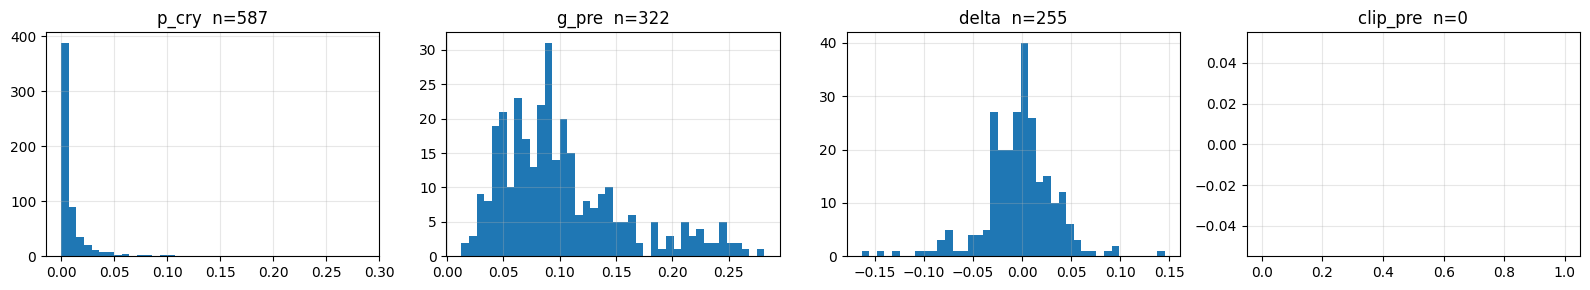

TH_CRY=0.40  TH_DELTA_HI=0.0222  TH_DELTA_LO=-0.0061
auto
uncertain     901
no_pre_cry     99
Name: count, dtype: int64


/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 52257 (\N{HANGUL SYLLABLE JJING}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 47548 (\N{HANGUL SYLLABLE RIM}) missing from font(s) DejaVu Sa

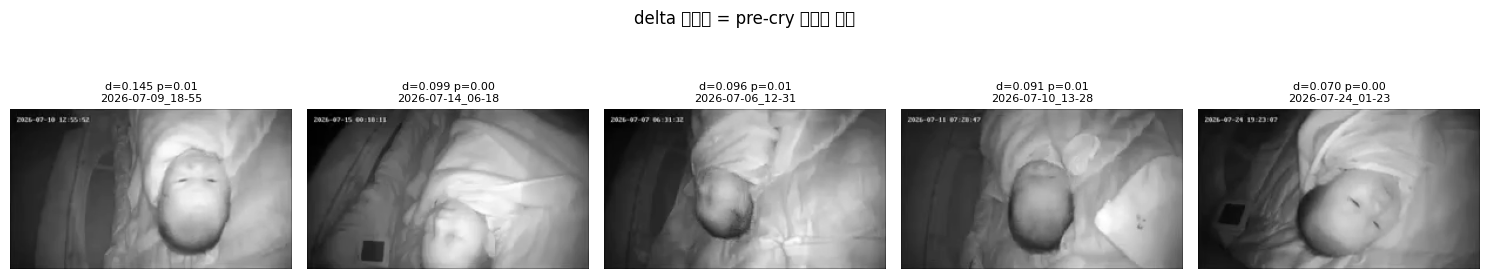

/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_1813/963787600.py:42: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans

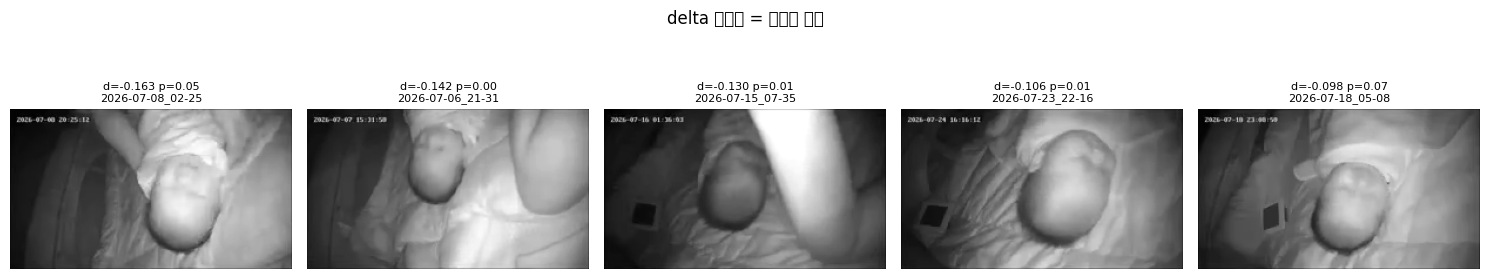

face_frac==0 비율: 0.414


In [9]:
# === D5_pre_cry: 검증 (분포 + 극단 사례) ==============================
import matplotlib.pyplot as plt
res = pd.read_csv(OUT_CSV)
ok = res[res['label'] != 'error']
print('행 %d (error %d) | 얼굴 검출률 평균 %.3f'
      % (len(res), (res['label'] == 'error').sum(), ok['face_frac'].mean()))

fig, axs = plt.subplots(1, 4, figsize=(16, 3))
for a, c in zip(axs, ['p_cry', 'g_pre', 'delta', 'clip_pre']):
    d = ok[c].dropna()
    a.hist(d, bins=40); a.set_title(f'{c}  n={len(d)}'); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

# 분포 기반으로 임계값 재산정 -> 최종 의사라벨 auto 컬럼
d_ok = ok['delta'].dropna()
TH_CRY = 0.40
TH_HI = float(d_ok.quantile(0.80)) if len(d_ok) > 20 else 0.03
TH_LO = float(d_ok.quantile(0.40)) if len(d_ok) > 20 else 0.00
pos = (res['p_cry'].fillna(0) >= TH_CRY) & (res['delta'] >= TH_HI)
neg = (res['p_cry'].fillna(0) < 0.10) & (res['delta'].fillna(0) <= min(TH_LO, 0.0))
res['auto'] = np.where(res['label'].eq('error'), 'error',
                       np.where(pos, 'pre_cry', np.where(neg, 'no_pre_cry', 'uncertain')))
print(f'TH_CRY={TH_CRY:.2f}  TH_DELTA_HI={TH_HI:.4f}  TH_DELTA_LO={TH_LO:.4f}')
print(res['auto'].value_counts())
res.to_csv(OUT_CSV, index=False)

def show_cases(rows, title):
    rows = rows.dropna(subset=['delta'])
    if len(rows) == 0:
        print('표시할 사례 없음:', title); return
    fig, axs = plt.subplots(1, len(rows), figsize=(3 * len(rows), 3.4))
    for a, (_, r) in zip(np.atleast_1d(axs), rows.iterrows()):
        try:
            vr = VideoReader(str(CLIPS / r['file']), ctx=cpu(0))
            fps = float(vr.get_avg_fps()) or 15.0
            t = (r['onset'] - 0.4) if np.isfinite(r['onset']) else 1.0
            a.imshow(vr[int(min(len(vr) - 1, max(0, t * fps)))].asnumpy())
        except Exception:
            a.text(.2, .5, 'read fail')
        a.set_title("d=%.3f p=%.2f\n%s" % (r['delta'], r['p_cry'], str(r['file'])[:16]), fontsize=8)
        a.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_cases(res.sort_values('delta', ascending=False).head(5), 'delta 최상위 = pre-cry 찡그림 후보')
show_cases(res.sort_values('delta').head(5), 'delta 최하위 = 평온한 얼굴')
print('face_frac==0 비율: %.3f' % float((ok['face_frac'] == 0).mean()))